Now i want to create all the same features as in the real dataset
https://www.kaggle.com/datasets/uciml/human-activity-recognition-with-smartphones?select=train.csv

Description of the dataset

Description of experiment
The experiments have been carried out with a group of 30 volunteers within an age bracket of 19-48 years. Each person performed six activities (WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS, SITTING, STANDING, LAYING) wearing a smartphone (Samsung Galaxy S II) on the waist. Using its embedded accelerometer and gyroscope, we captured 3-axial linear acceleration and 3-axial angular velocity at a constant rate of 50Hz. The experiments have been video-recorded to label the data manually. The obtained dataset has been randomly partitioned into two sets, where 70% of the volunteers was selected for generating the training data and 30% the test data.

The sensor signals (accelerometer and gyroscope) were pre-processed by applying noise filters and then sampled in fixed-width sliding windows of 2.56 sec and 50% overlap (128 readings/window). The sensor acceleration signal, which has gravitational and body motion components, was separated using a Butterworth low-pass filter into body acceleration and gravity. The gravitational force is assumed to have only low frequency components, therefore a filter with 0.3 Hz cutoff frequency was used. From each window, a vector of features was obtained by calculating variables from the time and frequency domain.



# 1. Make sure we have the same frequency (50 Hz)



count     31910.000000
mean          7.126154
std        1252.801938
min           0.003531
25%           0.020035
50%           0.020755
75%           0.029463
max      223780.552695
Name: dt, dtype: float64
Median delta time: 0.02075458300532773 seconds
Estimated frequency: 48.18212920699484 Hz


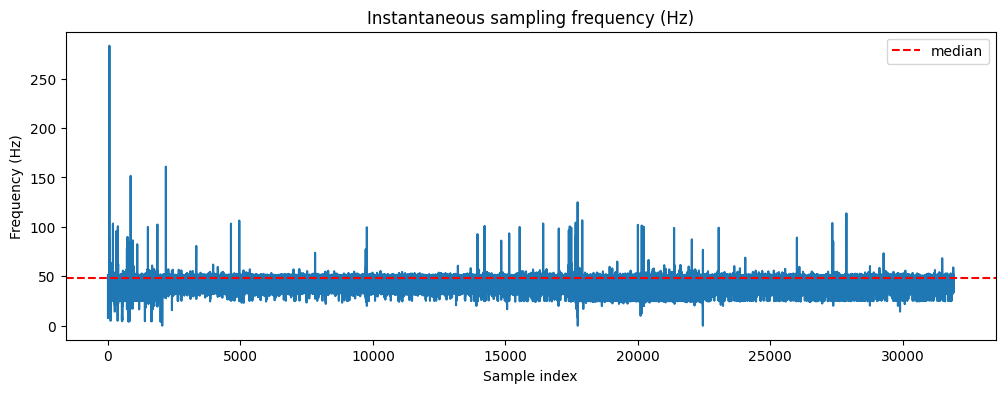

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_json("merged_sensor_data_labeled.json", convert_dates=False)

data = data.sort_values("timestampNanos")
data["ts"] = data["timestampNanos"] / 1e9
data["dt"] = data["ts"].diff() # with this line we substract each timestamp from the previous one so we get the time gaps.
# if there are negative gaps, that means the data is not sorted properly. if dt is very large, that means there was a recording pause.
# dt stands for delta time meaning the difference between consecutive timestamps in seconds (around 0.02s for 50Hz data)

# keep only positive gaps
nz = data.loc[data["dt"] > 0, "dt"] # nz means non-zero differences
freq = 1 / nz  # frequency is the inverse of delta time
print(nz.describe())

median_dt = nz.median()
print(f"Median delta time: {median_dt} seconds")

# to calculate frequency in Hz (samples per second), we take the inverse of median_dt so how many samples fit in
median_freq_hz = 1 / median_dt

print("Estimated frequency:", median_freq_hz, "Hz")


plt.figure(figsize=(12,4))
plt.plot(freq.reset_index(drop=True))
plt.title("Instantaneous sampling frequency (Hz)")
plt.xlabel("Sample index")
plt.ylabel("Frequency (Hz)")
plt.axhline(freq.median(), color="red", linestyle="--", label="median")
plt.legend()
plt.show()


In [2]:
data.describe()

,accelerometerX,accelerometerY,accelerometerZ,gyroscopeX,gyroscopeY,gyroscopeZ,timestamp,timestampNanos,ts,dt
count,102479.000000,102479.000000,102479.000000,102479.000000,102479.000000,102479.000000,1.024790e+05,1.024790e+05,102479.000000,102478.000000
mean,0.515906,9.629886,-1.289864,0.026531,-0.017108,0.036197,1.767187e+12,6.935610e+13,69356.103986,2.218970
std,1.797991,1.422566,1.894636,0.303132,0.642270,0.275341,1.922246e+06,1.038801e+14,103880.075741,699.086073
min,-19.490000,-17.760000,-16.130000,-12.490000,-5.600000,-6.360000,1.767182e+12,5.783872e+10,57.838721,0.000000
25%,-0.320000,9.540000,-1.960000,-0.020000,-0.130000,0.000000,1.767185e+12,7.611484e+11,761.148404,0.000000
50%,1.100000,9.820000,-1.630000,0.030000,-0.020000,0.030000,1.767188e+12,8.767888e+11,876.788750,0.000000
75%,1.370000,9.910000,-0.960000,0.070000,0.060000,0.080000,1.767188e+12,2.249083e+14,224908.292437,0.019979
max,15.719999,19.430000,15.210000,9.929999,10.809999,4.810000,1.767188e+12,2.274534e+14,227453.398620,223780.552695


The median is around 50Hz but the visualisation shows spikes and very irregular data - now we have to resample to get exactly 50Hz - also we need to consider big time gaps between recording sessions


In [3]:
# dedupe timestamps

data = pd.read_json("merged_sensor_data_labeled.json", convert_dates=False)

data = data.sort_values("timestampNanos")
data["ts"] = data["timestampNanos"] / 1e9
data["dt"] = data["ts"].diff() 

sensor_cols = [
    "accelerometerX","accelerometerY","accelerometerZ",
    "gyroscopeX","gyroscopeY","gyroscopeZ",
] # we're marking sensor columns because we want to average them when deduping

agg_dict = {col: "mean" for col in sensor_cols} # this line creates a dictionary mapping each sensor column to the "mean" aggregation function
print(agg_dict)
agg_dict["label"] = "first"
print(agg_dict)
data = (
    data
    .groupby("timestampNanos", as_index=False)
    .agg(agg_dict)
)
# we grouped the data by timestampNanos and averaged the sensor readings for duplicate timestamps, while keeping the first label.

# # use sensor time as index (monotonic)
data["t"] = pd.to_timedelta(data["timestampNanos"], unit="ns") # we convert nanoseconds to a timedelta object (pandas Timedelta) because it's easier to work with time intervals
data = data.set_index("t") # set the time column as the index of the dataframe for easier time-based slicing and analysis
data = data.sort_index() # ensure the data is sorted by time index

data.describe()

##################

{'accelerometerX': 'mean', 'accelerometerY': 'mean', 'accelerometerZ': 'mean', 'gyroscopeX': 'mean', 'gyroscopeY': 'mean', 'gyroscopeZ': 'mean'}
{'accelerometerX': 'mean', 'accelerometerY': 'mean', 'accelerometerZ': 'mean', 'gyroscopeX': 'mean', 'gyroscopeY': 'mean', 'gyroscopeZ': 'mean', 'label': 'first'}


,timestampNanos,accelerometerX,accelerometerY,accelerometerZ,gyroscopeX,gyroscopeY,gyroscopeZ
count,3.191100e+04,31911.000000,31911.000000,31911.000000,31911.000000,31911.000000,31911.000000
mean,1.010727e+14,0.202494,9.499257,-1.188910,0.017456,0.002240,0.032773
std,1.121761e+14,2.064408,1.855119,2.181294,0.365111,0.680942,0.335428
min,5.783872e+10,-19.490000,-17.760000,-16.130000,-12.490000,-5.600000,-6.360000
25%,8.178489e+11,-1.070000,9.290000,-1.950000,-0.040000,-0.130000,-0.010000
50%,1.005499e+12,0.940000,9.809999,-1.600000,0.020000,-0.020000,0.030000
75%,2.272558e+14,1.340000,9.920000,-0.760000,0.070000,0.120000,0.090000
max,2.274534e+14,15.719999,19.430000,15.210000,9.929999,10.809999,4.810000


In [4]:
########################### RESMAMPLE #####################################################
# resample sensors to 20 ms grid

# 1) put data on 20ms bins, averaging any points that fall in each bin
resampled = (
    data[sensor_cols]
        .resample("20ms")
        .mean()              # <--- this is the key, NOT asfreq()
)

# 2) optional: smooth tiny gaps by interpolation
resampled = resampled.interpolate("time", limit=500)



resampled = resampled.dropna(how="all", subset=sensor_cols)

resampled["label"] = data["label"].resample("20ms").first()

resampled.describe()



# # here we convert 
# # drop rows that are still all NaN (these are big gaps, e.g. between recordings)
resampled = resampled.dropna(how="all", subset=sensor_cols)






In [5]:
resampled.describe()

,accelerometerX,accelerometerY,accelerometerZ,gyroscopeX,gyroscopeY,gyroscopeZ
count,40736.000000,40736.000000,40736.000000,40736.000000,40736.000000,40736.000000
mean,0.075846,9.381905,-0.997027,0.018707,0.001998,0.031549
std,2.190809,1.987107,2.420582,0.361487,0.671298,0.331797
min,-19.490000,-17.760000,-16.130000,-12.490000,-5.600000,-6.360000
25%,-1.200000,9.150000,-1.920000,-0.040000,-0.120000,-0.010000
50%,0.810000,9.800000,-1.580000,0.020000,-0.020000,0.030000
75%,1.325000,9.910000,-0.650000,0.080000,0.110000,0.080000
max,15.719999,19.430000,15.210000,9.929999,10.809999,4.810000


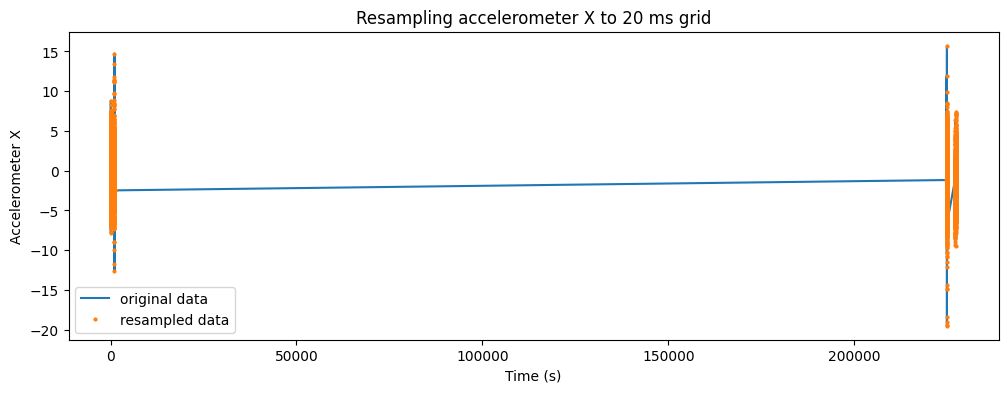

In [6]:

resampled_segment = resampled
# visualize resampling result
plt.figure(figsize=(12,4))
plt.plot(data.index.total_seconds()[:40736], data["accelerometerX"][:40736], "-", label="original data")
plt.plot(resampled_segment.index.total_seconds()[:40736], resampled_segment["accelerometerX"][:40736], "o", markersize=2, label="resampled data")

plt.xlabel("Time (s)")
plt.ylabel("Accelerometer X")
plt.legend()
plt.title("Resampling accelerometer X to 20 ms grid")
plt.show()


In [8]:
resampled.head(50)

,accelerometerX,accelerometerY,accelerometerZ,gyroscopeX,gyroscopeY,gyroscopeZ,label
t,,,,,,,
0 days 00:00:57.838720972,-0.835000,5.255000,8.400000,0.000000,-0.410000,0.140000,STANDING
0 days 00:00:57.858720972,-0.870000,5.400000,8.670000,0.000000,-0.410000,0.140000,STANDING
0 days 00:00:57.878720972,-1.237143,5.412857,8.914286,-0.152857,-0.194286,0.032857,None
0 days 00:00:57.898720972,-1.604286,5.425714,9.158571,-0.305714,0.021429,-0.074286,None
0 days 00:00:57.918720972,-1.971428,5.438571,9.402857,-0.458571,0.237143,-0.181429,None
0 days 00:00:57.938720972,-2.338571,5.451429,9.647143,-0.611429,0.452857,-0.288571,None
0 days 00:00:57.958720972,-2.705714,5.464286,9.891429,-0.764286,0.668571,-0.395714,None
0 days 00:00:57.978720972,-3.072857,5.477143,10.135714,-0.917143,0.884286,-0.502857,None
0 days 00:00:57.998720972,-3.440000,5.490000,10.380000,-1.070000,1.100000,-0.610000,STANDING


Median delta time: 0.02 seconds
Estimated frequency: 50.0 Hz


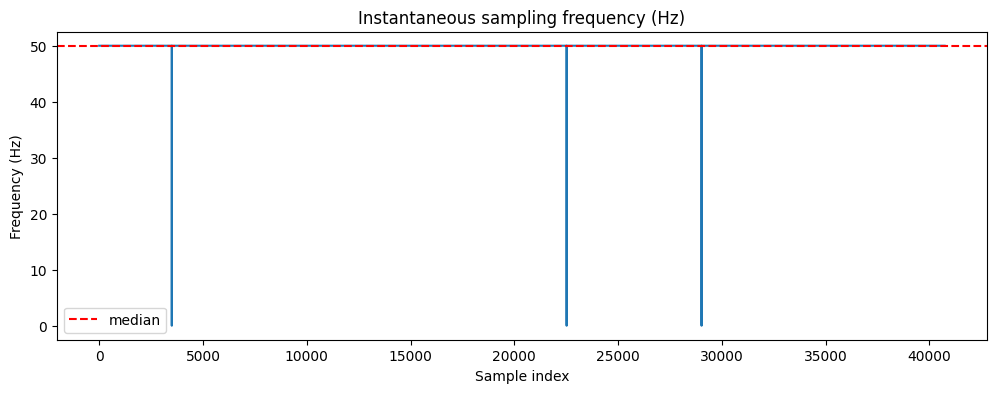

In [20]:
data_after_resample = resampled.sort_values("t")

data_after_resample["dt"] = data_after_resample.index.diff() # with this line we substract each timestamp from the previous one so we get the time gaps.

data_after_resample["dt"] = data_after_resample["dt"].fillna(pd.Timedelta(0))

data_after_resample.head()
# Convert timedelta to seconds, then calculate frequency
data_after_resample["dt_seconds"] = data_after_resample["dt"].dt.total_seconds()

# Calculate frequency (Hz) - drop the first row to avoid division by zero
freq = 1 / data_after_resample["dt_seconds"].iloc[1:]

median_dt = data_after_resample["dt_seconds"].median()
print(f"Median delta time: {median_dt} seconds")

# # to calculate frequency in Hz (samples per second), we take the inverse of median_dt so how many samples fit in
median_freq_hz = 1 / median_dt

print("Estimated frequency:", median_freq_hz, "Hz")


plt.figure(figsize=(12,4))
plt.plot(freq.reset_index(drop=True))
plt.title("Instantaneous sampling frequency (Hz)")
plt.xlabel("Sample index")
plt.ylabel("Frequency (Hz)")
plt.axhline(freq.median(), color="red", linestyle="--", label="median")
plt.legend()
plt.show()

The frequency drops mark boundaries between sessions


# 2 create sliding windows

 sampled in fixed-width sliding windows of 2.56 sec and 50% overlap (128 readings/window).

In [21]:
data_after_resample.head()

,accelerometerX,accelerometerY,accelerometerZ,gyroscopeX,gyroscopeY,gyroscopeZ,label,dt,dt_seconds
t,,,,,,,,,
0 days 00:00:57.838720972,-0.835000,5.255000,8.400000,0.000000,-0.410000,0.140000,STANDING,0 days 00:00:00,0.00
0 days 00:00:57.858720972,-0.870000,5.400000,8.670000,0.000000,-0.410000,0.140000,STANDING,0 days 00:00:00.020000,0.02
0 days 00:00:57.878720972,-1.237143,5.412857,8.914286,-0.152857,-0.194286,0.032857,None,0 days 00:00:00.020000,0.02
0 days 00:00:57.898720972,-1.604286,5.425714,9.158571,-0.305714,0.021429,-0.074286,None,0 days 00:00:00.020000,0.02
0 days 00:00:57.918720972,-1.971428,5.438571,9.402857,-0.458571,0.237143,-0.181429,None,0 days 00:00:00.020000,0.02


In [22]:
import numpy as np
import pandas as pd

sensor_cols = [
    "accelerometerX","accelerometerY","accelerometerZ",
    "gyroscopeX","gyroscopeY","gyroscopeZ",
]

# if you already have resampled, start from there:
df_sliding_window = data_after_resample.copy()

# ensure it's sorted by time index
df_sliding_window = df_sliding_window.sort_index()

# compute gaps between samples (in seconds)
df_sliding_window["dt"] = df_sliding_window.index.to_series().diff()
df_sliding_window["dt_seconds"] = df_sliding_window["dt"].dt.total_seconds().fillna(0)
# anything bigger than, say, 0.2s is a "break" between sessions
GAP_THRESHOLD = 0.2  # 10x your normal 0.02s step

df_sliding_window["session_break"] = df_sliding_window["dt_seconds"] > GAP_THRESHOLD
# session_id increments every time we hit a break
df_sliding_window["session_id"] = df_sliding_window["session_break"].cumsum().astype(int)

print(df_sliding_window[["dt_seconds", "session_id"]].head(10))
print("Number of sessions:", df_sliding_window["session_id"].nunique())

                           dt_seconds  session_id
t                                                
0 days 00:00:57.838720972        0.00           0
0 days 00:00:57.858720972        0.02           0
0 days 00:00:57.878720972        0.02           0
0 days 00:00:57.898720972        0.02           0
0 days 00:00:57.918720972        0.02           0
0 days 00:00:57.938720972        0.02           0
0 days 00:00:57.958720972        0.02           0
0 days 00:00:57.978720972        0.02           0
0 days 00:00:57.998720972        0.02           0
0 days 00:00:58.018720972        0.02           0
Number of sessions: 4


In [28]:


df_sliding_window["dt"].iloc[0] = pd.Timedelta(0)

df_sliding_window.info()

<class 'pandas.core.frame.DataFrame'>
TimedeltaIndex: 40736 entries, 0 days 00:00:57.838720972 to 2 days 15:10:53.378720972
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype          
---  ------          --------------  -----          
 0   accelerometerX  40736 non-null  float64        
 1   accelerometerY  40736 non-null  float64        
 2   accelerometerZ  40736 non-null  float64        
 3   gyroscopeX      40736 non-null  float64        
 4   gyroscopeY      40736 non-null  float64        
 5   gyroscopeZ      40736 non-null  float64        
 6   label           30800 non-null  object         
 7   dt              40736 non-null  timedelta64[ns]
 8   dt_seconds      40736 non-null  float64        
 9   session_break   40736 non-null  bool           
 10  session_id      40736 non-null  int64          
dtypes: bool(1), float64(7), int64(1), object(1), timedelta64[ns](1)
memory usage: 3.5+ MB


C:\Users\patry\AppData\Local\Temp\ipykernel_13608\105348363.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sliding_window["dt"].iloc[0] = pd.Timedelta(0)


In [31]:
df_sliding_window["label"].ffill(inplace=True)
# forward fill

df_sliding_window.info()

<class 'pandas.core.frame.DataFrame'>
TimedeltaIndex: 40736 entries, 0 days 00:00:57.838720972 to 2 days 15:10:53.378720972
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype          
---  ------          --------------  -----          
 0   accelerometerX  40736 non-null  float64        
 1   accelerometerY  40736 non-null  float64        
 2   accelerometerZ  40736 non-null  float64        
 3   gyroscopeX      40736 non-null  float64        
 4   gyroscopeY      40736 non-null  float64        
 5   gyroscopeZ      40736 non-null  float64        
 6   label           40736 non-null  object         
 7   dt              40736 non-null  timedelta64[ns]
 8   dt_seconds      40736 non-null  float64        
 9   session_break   40736 non-null  bool           
 10  session_id      40736 non-null  int64          
dtypes: bool(1), float64(7), int64(1), object(1), timedelta64[ns](1)
memory usage: 3.5+ MB


In [32]:
WINDOW_SIZE = 128   # samples per window
STEP_SIZE   = 64    # stride (50% overlap)

X_windows = []   # list of (128, num_features) arrays
y_windows = []   # list of labels

for sid, group in df_sliding_window.groupby("session_id"):
    # make sure there are enough samples in this session
    if len(group) < WINDOW_SIZE:
        continue

    # ensure we use only rows with valid sensor values
    group = group.dropna(subset=sensor_cols)

    # if after dropping NaN we don't have enough, skip
    if len(group) < WINDOW_SIZE:
        continue

    # convert to numpy for fast slicing
    values = group[sensor_cols].to_numpy()
    labels = group["label"].to_numpy()

    # sliding windows
    for start in range(0, len(group) - WINDOW_SIZE + 1, STEP_SIZE):
        end = start + WINDOW_SIZE

        window_vals = values[start:end]       # shape: (128, 6)
        window_labels = labels[start:end]

        # majority label in the window
        window_label = pd.Series(window_labels).mode().iloc[0]

        X_windows.append(window_vals)
        y_windows.append(window_label)

X = np.stack(X_windows)      # shape: (n_windows, 128, 6)
y = np.array(y_windows)      # shape: (n_windows,)

print("Number of windows:", X.shape[0])
print("Window shape:", X.shape[1:])
print("Example labels:", np.unique(y))

Number of windows: 631
Window shape: (128, 6)
Example labels: ['CUTOUT' 'SITTING' 'STANDING' 'WALKING' 'WALKING_DOWNSTAIRS']


In [33]:
df_sliding_window = df_sliding_window[df_sliding_window["label"] != "CUTOUT"]

In [34]:
df_sliding_window.to_csv("gyro_acc_resampled_sliding_window.csv", index=True)